In [5]:
import torch
import time
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [6]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define class names (same order as folder names)
class_names = ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia', 'Tuberculosis']

# Training transform (with light augmentation)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Validation & test transform (no augmentation)
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load datasets
train_dataset = datasets.ImageFolder(root='data1/train', transform=train_transform)
val_dataset = datasets.ImageFolder(root='data1/val', transform=test_transform)
test_dataset = datasets.ImageFolder(root='data1/test', transform=test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)


In [7]:
# Define the CNN Model
class DeeperCNN(nn.Module):
    def __init__(self, num_classes):
        super(DeeperCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # Input: (1, 160, 160) → (16, 160, 160)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (16, 80, 80)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (32, 80, 80)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (32, 40, 40)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (64, 40, 40)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (64, 20, 20)

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (128, 20, 20)
            nn.ReLU(),
            nn.MaxPool2d(2)                               # (128, 10, 10)
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),                                 # (128 * 10 * 10) = 12800
            nn.Linear(128 * 10 * 10, 256),
            nn.ReLU(),
            nn.Dropout(0.5),  # Helps prevent overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x


# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set Number of Classes (5 total)
num_classes = 5


# Initialize Model
model = DeeperCNN(num_classes=num_classes).to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5):
    best_val_acc = 0.0
    early_stop_counter = 0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    print("Starting Training...")

    for epoch in range(num_epochs):
        start_time = time.time()

        # TRAINING
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # VALIDATION
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            early_stop_counter = 0
            torch.save(model.state_dict(), "best_model11.pth")
            print(f"Saved new best model with Val Acc: {val_acc:.2f}%")
        else:
            early_stop_counter += 1
            print(f"No improvement ({early_stop_counter}/{patience})")

            if early_stop_counter >= patience:
                print(f"\n Early stopping at epoch {epoch+1}")
                break

        epoch_time = time.time() - start_time

        print(f"\n Epoch [{epoch+1}/{num_epochs}] - Time: {epoch_time:.2f}s")
        print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f" Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    print("\n Training Complete.")
    print(f" Best Validation Accuracy: {best_val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [10]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    device, 
    num_epochs=25, 
    patience=5  # stop early if val acc doesn't improve for 5 epochs
)

Starting Training...
Saved new best model with Val Acc: 82.32%

 Epoch [1/25] - Time: 274.62s
 Train Loss: 0.6578 | Train Acc: 73.13%
 Val   Loss: 0.4224 | Val   Acc: 82.32%
Saved new best model with Val Acc: 85.98%

 Epoch [2/25] - Time: 200.30s
 Train Loss: 0.4140 | Train Acc: 83.27%
 Val   Loss: 0.3503 | Val   Acc: 85.98%
Saved new best model with Val Acc: 87.36%

 Epoch [3/25] - Time: 204.76s
 Train Loss: 0.3639 | Train Acc: 85.44%
 Val   Loss: 0.3162 | Val   Acc: 87.36%
Saved new best model with Val Acc: 90.19%

 Epoch [4/25] - Time: 194.08s
 Train Loss: 0.3194 | Train Acc: 87.02%
 Val   Loss: 0.2790 | Val   Acc: 90.19%
No improvement (1/5)

 Epoch [5/25] - Time: 186.62s
 Train Loss: 0.2908 | Train Acc: 88.50%
 Val   Loss: 0.2773 | Val   Acc: 89.23%
Saved new best model with Val Acc: 91.30%

 Epoch [6/25] - Time: 188.58s
 Train Loss: 0.2650 | Train Acc: 89.53%
 Val   Loss: 0.2390 | Val   Acc: 91.30%
No improvement (1/5)

 Epoch [7/25] - Time: 194.19s
 Train Loss: 0.2600 | Train Ac

Classification Report:

              precision    recall  f1-score   support

    Covid-19     0.8900    0.8900    0.8900       300
   Emphysema     0.8790    0.8720    0.8755       250
      Normal     0.9733    0.9733    0.9733       300
   Pneumonia     0.9700    0.9700    0.9700       300
Tuberculosis     0.9896    0.9965    0.9931       287

    accuracy                         0.9422      1437
   macro avg     0.9404    0.9404    0.9404      1437
weighted avg     0.9421    0.9422    0.9422      1437

Overall Accuracy: 94.22%


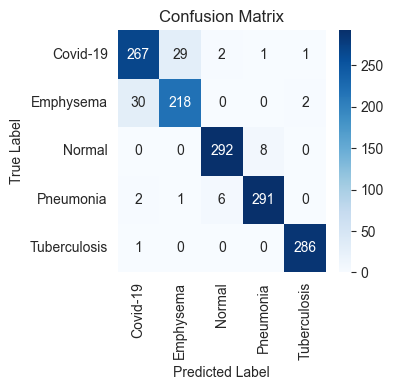

In [11]:
# Load the best model
model.load_state_dict(torch.load("best_model1.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


# 1. Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Overall Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc*100:.2f}%")


# 2. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

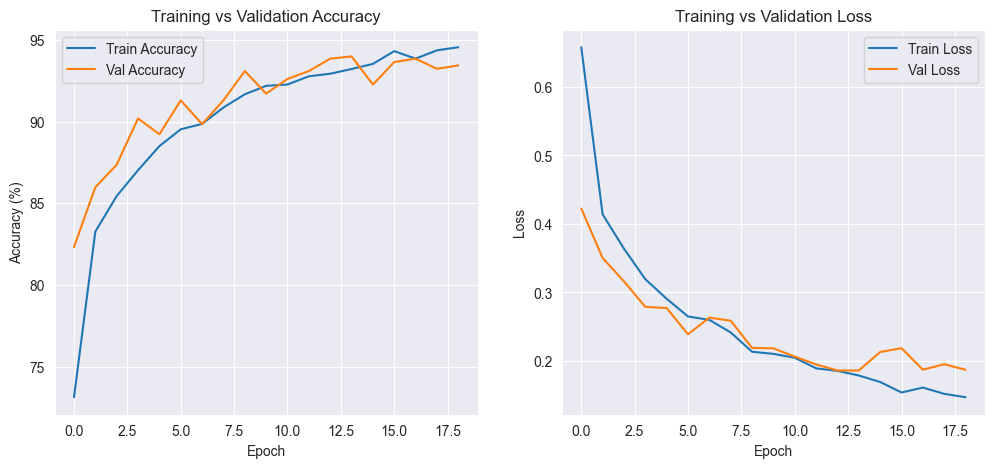

In [12]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()